<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Load dataset
file_path = '/content/census-income.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country Unnamed: 14  
0          2174             0              40  United-States       <=50K  
1             0             0   

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  Unnamed: 14     32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
                age        fnlwgt  education-num  capital-gain  capital-loss

In [ ]:
df.rename(columns={'Unnamed: 14': 'income'}, inplace=True)

In [ ]:
# Replace ? with NaN
df.replace(' ?', np.nan, inplace=True)

# Check missing values
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


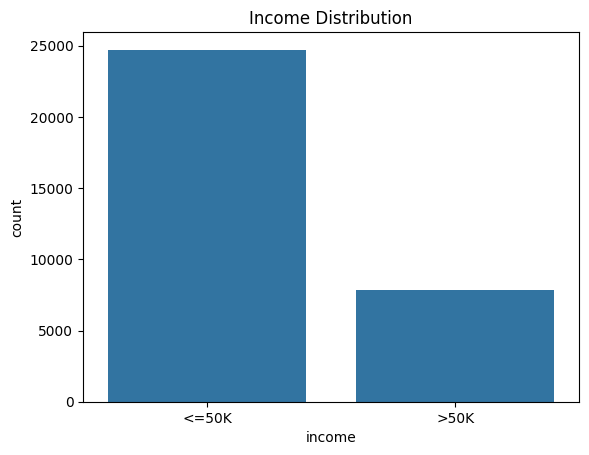

In [ ]:
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

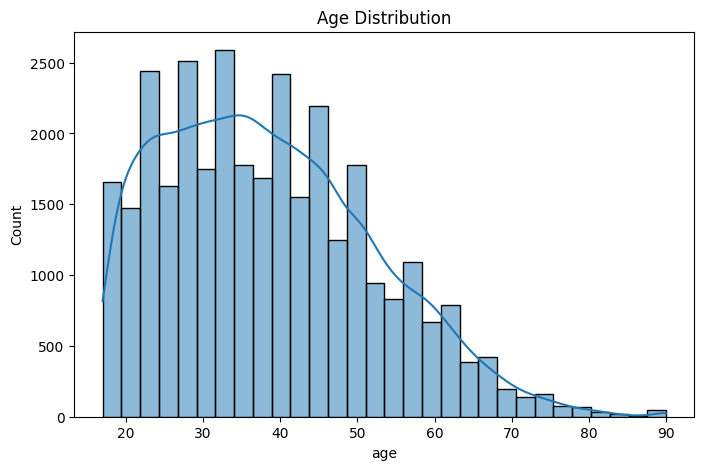

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

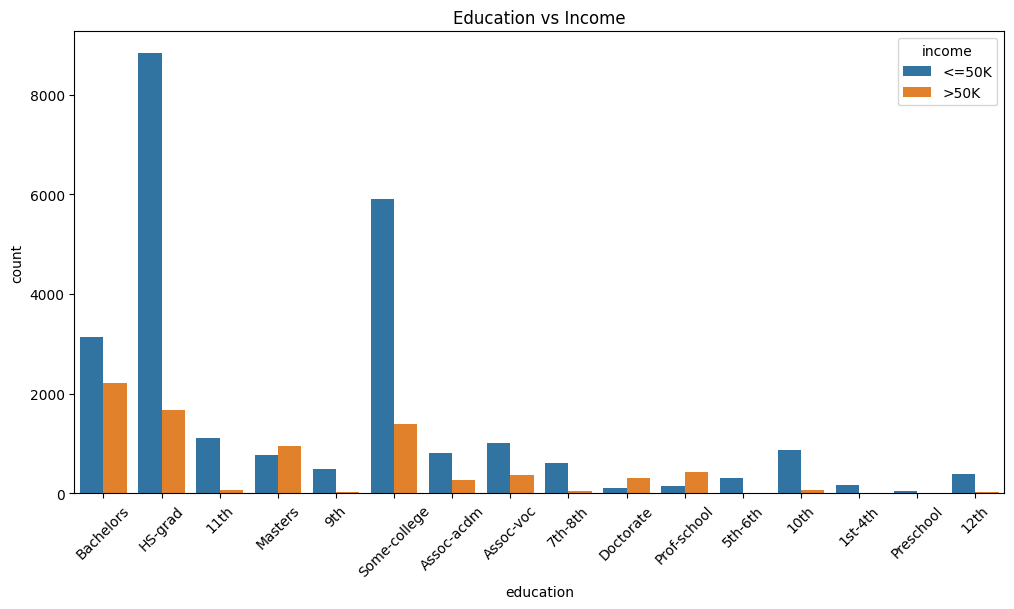

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title('Education vs Income')
plt.show()

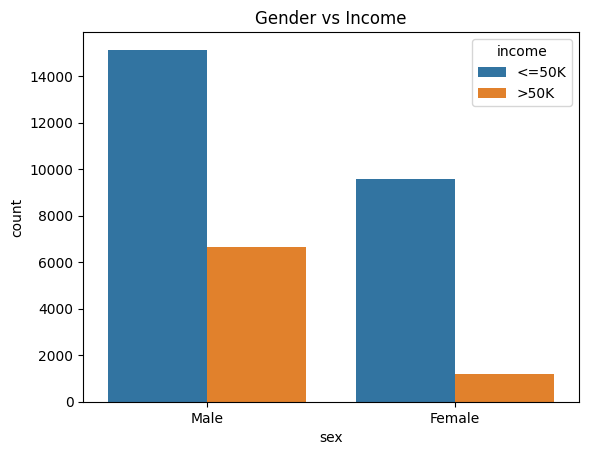

In [ ]:
sns.countplot(x='sex', hue='income', data=df)
plt.title('Gender vs Income')
plt.show()

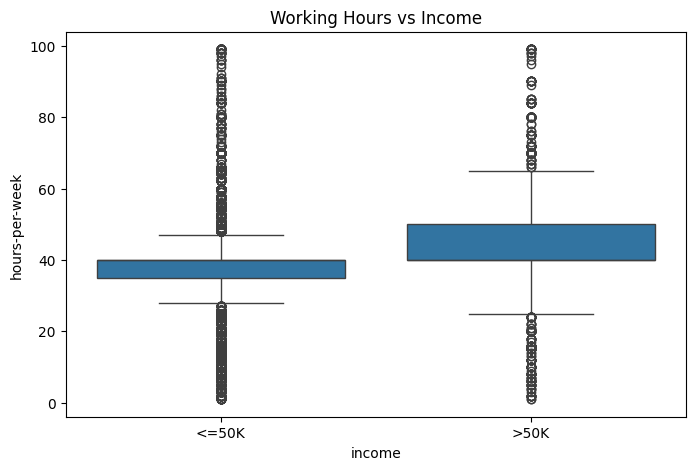

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title('Working Hours vs Income')
plt.show()

In [ ]:
X = df.drop('income', axis=1)
y = df['income']

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print('Numerical Columns:', numerical_cols)
print('Categorical Columns:', categorical_cols)

Numerical Columns: Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical Columns: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


In [ ]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.855980346998311


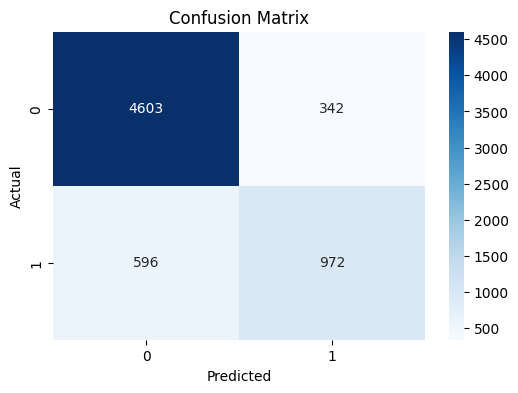

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Convert target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

auc = roc_auc_score(y_test_encoded, y_prob)
print('ROC-AUC Score:', auc)

ROC-AUC Score: 0.909838452570108


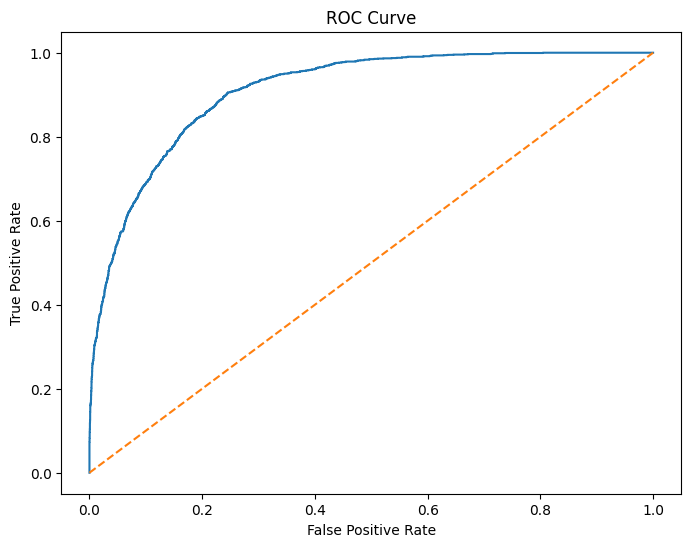

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("census-income.csv")

count = df[
    (df['marital-status'].str.strip() == 'Never-married') &
    (df['hours-per-week'] < 20)
].shape[0]

print(count)

907


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Airport_Passengers_Satisfication.csv")

# Filter female passengers
female_df = df[df['Gender'] == 'Female']

# Count dissatisfied female passengers
dissatisfied_count = female_df[
    female_df['satisfaction'] == 'neutral or dissatisfied'
].shape[0]

# Total female passengers
total_female = female_df.shape[0]

# Percentage calculation
percentage = (dissatisfied_count / total_female) * 100

print("Percentage of dissatisfied female passengers:")
print(round(percentage, 2), "%")

Percentage of dissatisfied female passengers:
0.0 %


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Airport_Passengers_Satisfication.csv")

# 14 columns with ratings from 1 to 5
rating_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

# Create average score column
df['ave_score'] = df[rating_cols].mean(axis=1)

# Convert satisfaction column
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

# Independent and dependent variables
X = df[['ave_score']]
y = df['satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Build Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.722671285604311


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Airport_Passengers_Satisfication.csv")

# 14 rating columns
rating_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

# Convert target variable
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

# Features and target
X = df[rating_cols]
y = df['satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=24
)

# Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=24
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9358398562812781


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Load dataset
df = pd.read_csv("Airport_Passengers_Satisfication.csv")

# Convert target column
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

# Drop columns
df.drop(['id', 'Arrival Delay in Minutes'], axis=1, inplace=True)

# Apply one-hot encoding
df = pd.get_dummies(df)

# Features and target
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=12
)

# Random Forest model
model = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    random_state=12
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# F1 score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9513030528667163
